In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [4]:
file_csv = '../../../../../../../data/phen/original/phenotypic_weather_obregon_151617_seven.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.LINEAR)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic_weather/svr/week


/usr/local/lib/python3.12/site-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: [322]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Launched SVR

In [5]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [6]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [7]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 58.60346337683755
R2 -> 0.6434409540838606
MAPE -> 0.07356858921349828


{'d2_absolute_error_score': 0.38021276966701734,
 'd2_pinball_score': 0.38021276966701734,
 'd2_tweedie_score': 0.6434409540838606,
 'explained_variance_score': 0.6463713760777028,
 'max_error': 222.05955187907273,
 'mean_absolute_error': 43.2472072335361,
 'mean_absolute_percentage_error': 0.07356858921349828,
 'mean_gamma_deviance': 0.009230926018700758,
 'mean_poisson_deviance': 5.561515215627996,
 'mean_squared_error': 3434.36591976034,
 'mean_squared_log_error': 0.009604790233270967,
 'median_absolute_error': 31.834293242743044,
 'r2_score': 0.6434409540838606,
 'root_mean_squared_error': 58.60346337683755,
 'root_mean_squared_log_error': 0.09800403171947043}

Plots:

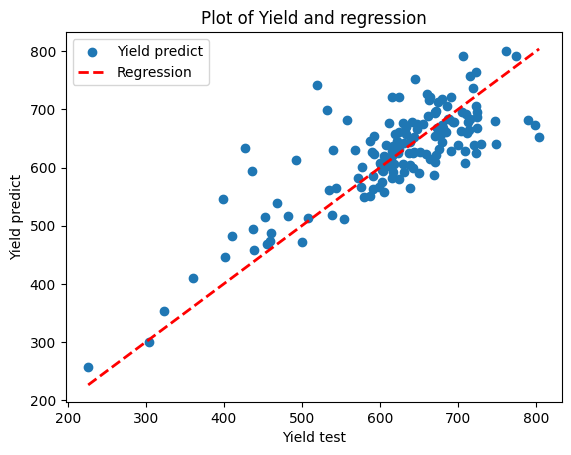

In [8]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

In [9]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
#metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [10]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 427.0, 'predict': 632.8237358997127, 'error': 0.48202280070190323},
 {'truth': 519.2414,
  'predict': 741.3009518790727,
  'error': 0.42766149209033166},
 {'truth': 398.2896,
  'predict': 545.1848562483882,
  'error': 0.3688151943921915},
 {'truth': 436.0, 'predict': 594.780682282975, 'error': 0.36417587679581426},
 {'truth': 532.0, 'predict': 699.711623194125, 'error': 0.3152474120190319},
 {'truth': 491.9464,
  'predict': 612.5002843482768,
  'error': 0.24505491725984127},
 {'truth': 557.3696,
  'predict': 681.9640029074641,
  'error': 0.22354000452745196},
 {'truth': 804.0, 'predict': 652.8476436998527, 'error': 0.1880004431593872},
 {'truth': 409.865,
  'predict': 482.2771402684681,
  'error': 0.17667314913073348},
 {'truth': 615.0, 'predict': 720.7154776284442, 'error': 0.17189508557470604},
 {'truth': 540.0, 'predict': 630.7490320906126, 'error': 0.168053763130764},
 {'truth': 645.0, 'predict': 751.5104005009434, 'error': 0.16513240387743167},
 {'truth': 799.0, 'predic